# Training History

Per-step training losses, validation loss, and adaptive weight $w$.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.chdir(os.path.join(os.getcwd(), '..'))

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',
    'font.size': 11,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
    'axes.grid': False,
    'lines.linewidth': 1.4,
})

In [ ]:
OUTPUTS_DIR = "outputs"
FRACTION = 0.1        # <-- change to plot different fractions

# Each entry: experiment_name, mode, display label
# experiment_name matches the output folder (from config experiment.name)
EXPERIMENTS = [
    # MAE
    {"name": "mae_ucm_mlc", "mode": "semi_supervised",     "label": "MAE Semi-Sup"},
    {"name": "mae_ucm_mlc", "mode": "supervised",          "label": "MAE Supervised"},
    {"name": "mae_ucm_mlc", "mode": "supervised_baseline", "label": "MAE Baseline"},
    # I-JEPA (uncomment when results available)
    # {"name": "ijepa_ucm_mlc", "mode": "semi_supervised",     "label": "IJEPA Semi-Sup"},
    # {"name": "ijepa_ucm_mlc", "mode": "supervised",          "label": "IJEPA Supervised"},
    # {"name": "ijepa_ucm_mlc", "mode": "supervised_baseline", "label": "IJEPA Baseline"},
]

In [3]:
MODE_C = {"semi_supervised": "#2176AE", "supervised": "#E8871E",
          "supervised_baseline": "#57A773"}
LOSS_C = {"loss": "#2176AE", "r_loss": "#D64933", "c_loss": "#57A773"}
LOSS_L = {"loss": r"$\mathcal{L}_{\mathrm{total}}$",
          "r_loss": r"$\mathcal{L}_{\mathrm{rec}}$",
          "c_loss": r"$\mathcal{L}_{\mathrm{cls}}$"}

def load_log(exp_name, mode, version=0):
    p = os.path.join(OUTPUTS_DIR, exp_name, mode, f"fl_{FRACTION}",
                     "logs", f"version_{version}", "metrics.csv")
    if not os.path.exists(p):
        return None
    return pd.read_csv(p)

def get_step(df, col):
    if col not in df.columns: return None
    d = df[["step", col]].dropna(subset=[col])
    return d.rename(columns={col: col.replace('_step', '')}) if not d.empty else None

def get_epoch(df, col):
    if col not in df.columns: return None
    d = df[["epoch", col]].dropna(subset=[col])
    if d.empty: return None
    return d.groupby("epoch").mean().reset_index().rename(columns={col: col.replace('_epoch', '')})

fl_str = f"$f_l$={int(FRACTION*100)}%"

## Training loss (per step)

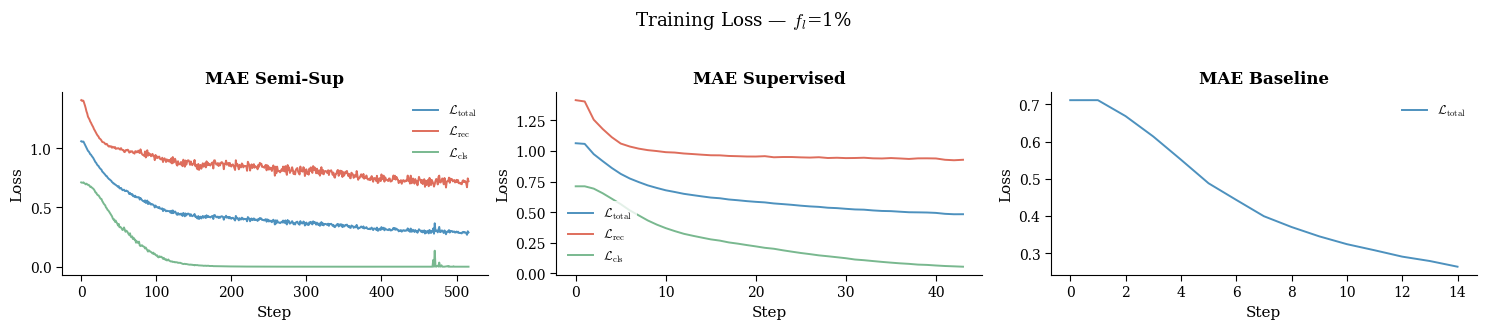

In [4]:
n = len(EXPERIMENTS)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 3.2), squeeze=False)

for i, exp in enumerate(EXPERIMENTS):
    ax = axes[0, i]
    df = load_log(exp["name"], exp["mode"])
    if df is None:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        continue
    for key in ["loss", "r_loss", "c_loss"]:
        d = get_step(df, f"{key}_step")
        if d is not None:
            ax.plot(d["step"], d[key], label=LOSS_L.get(key, key),
                    color=LOSS_C.get(key), alpha=0.8)
    ax.set_xlabel(r"Step")
    ax.set_ylabel(r"Loss")
    ax.set_title(exp["label"])
    ax.legend(frameon=True, edgecolor="none", facecolor="white")

fig.suptitle(f"Training Loss — {fl_str}", y=1.02)
plt.tight_layout()
plt.show()

## Validation loss

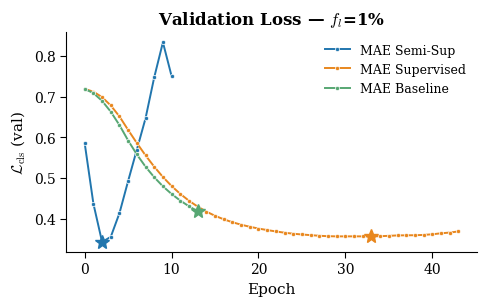

In [5]:
fig, ax = plt.subplots(figsize=(5, 3.2))

for exp in EXPERIMENTS:
    df = load_log(exp["name"], exp["mode"])
    if df is None: continue
    d = get_epoch(df, "val_loss")
    if d is None: continue
    c = MODE_C.get(exp["mode"], "#888")
    ax.plot(d["epoch"], d["val_loss"], label=exp["label"], color=c,
            marker="o", markersize=3, markeredgecolor="white", markeredgewidth=0.5)
    bi = d["val_loss"].idxmin()
    ax.plot(d.loc[bi, "epoch"], d.loc[bi, "val_loss"],
            marker="*", markersize=10, color=c, zorder=5)

ax.set_xlabel(r"Epoch")
ax.set_ylabel(r"$\mathcal{L}_{\mathrm{cls}}$ (val)")
ax.set_title(f"Validation Loss — {fl_str}")
ax.legend(frameon=True, edgecolor="none", facecolor="white")
plt.tight_layout()
plt.show()

## Adaptive weight $w$ (per step)

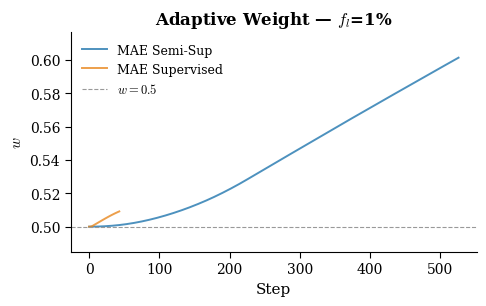

In [6]:
fig, ax = plt.subplots(figsize=(5, 3.2))
has_data = False
all_w = []

for exp in EXPERIMENTS:
    df = load_log(exp["name"], exp["mode"])
    if df is None: continue
    d = get_step(df, "w_step")
    if d is not None:
        ax.plot(d["step"], d["w"], label=exp["label"],
                color=MODE_C.get(exp["mode"], "#7B2D8E"), alpha=0.8)
        all_w.extend(d["w"].values)
        has_data = True

if has_data:
    w_min, w_max = min(all_w), max(all_w)
    pad = max((w_max - w_min) * 0.15, 0.01)
    ax.set_ylim(w_min - pad, w_max + pad)
    ax.axhline(0.5, color="#999", linestyle="--", linewidth=0.8, label=r"$w=0.5$")
    ax.set_xlabel(r"Step")
    ax.set_ylabel(r"$w$")
    ax.set_title(f"Adaptive Weight — {fl_str}")
    ax.legend(frameon=True, edgecolor="none", facecolor="white")
else:
    ax.text(0.5, 0.5, r"No $w$ logged", ha="center", va="center",
            fontsize=11, color="#888", transform=ax.transAxes)

plt.tight_layout()
plt.show()